# Scatterplot motif concordance

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.legend_handler import HandlerLine2D
from matplotlib import font_manager
import seaborn as sns
from glob import glob
from collections import defaultdict
import subprocess
from itertools import chain
from pathlib import Path
from tqdm.auto import tqdm
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio

font_files = font_manager.findSystemFonts(fontpaths='/home/vladimirnoz/Projects/Codebook_Perspectives/fonts')
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

os.chdir('/home/vladimirnoz/Projects/Codebook_Perspectives/AS_CHS_GHTS/')
sns.set_style('whitegrid')

In [9]:
SELEX_FIT = Path('as_tables/selex/')
CHIPSEQ_FIT = Path('as_tables/chipseq/')
chipseq = glob(f'{CHIPSEQ_FIT}/ASB_motifs/*.tsv')
selex = glob(f'{SELEX_FIT}/ASB_motifs/*.tsv')
chipseq_tfs = set(map(lambda x: x.split('/')[-1], chipseq))
selex_tfs = set(map(lambda x: x.split('/')[-1], selex))
intersections = chipseq_tfs.intersection(selex_tfs)
len(selex_tfs), len(chipseq_tfs), len(intersections)

(178, 155, 127)

In [10]:
def fix_concordance(x, motif_fc):
    if abs(motif_fc) < -2.5:
        return 'No Hit'
    if x == 'Weak Concordant':
        return 'Concordant'
    if x == 'Weak Discordant':
        return 'Discordant'
    return x


table = []
for tf in chipseq_tfs:
    tf = str(CHIPSEQ_FIT / 'ASB_motifs' / tf)
    df = pd.read_table(tf).query('fdr_comb_pval < 0.05').query('motif_conc != "No Hit"')
    if len(df) < 1:
        continue
    df['TF'] = tf.split('/')[-1][:-4]
    df['signed_pvalue'] = df.apply(lambda x: -np.log10(x['comb_pval']) * (int(x['pref_allele'] == 'alt')*2 - 1), axis=1)
    df['motif_conc'] = df.apply(lambda row: fix_concordance(row['motif_conc'], row['motif_fc']), axis=1)
    df['exp'] = 'chipseq'
    table.append(df)
for tf in selex_tfs:
    tf = str(SELEX_FIT / 'ASB_motifs' / tf)
    df = pd.read_table(tf).query('fdr_comb_pval < 0.05').query('motif_conc != "No Hit"')
    if len(df) < 1:
        continue
    df['TF'] = tf.split('/')[-1][:-4]
    df['signed_pvalue'] = df.apply(lambda x: -np.log10(x['comb_pval']) * (int(x['pref_allele'] == 'alt')*2 - 1), axis=1)
    df['motif_conc'] = df.apply(lambda row: fix_concordance(row['motif_conc'], row['motif_fc']), axis=1)
    df['exp'] = 'selex'
    table.append(df)
table = pd.concat(table)
df = table

60
40
20
0
20
40
60


/tmp/ipykernel_1132383/3269565967.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)


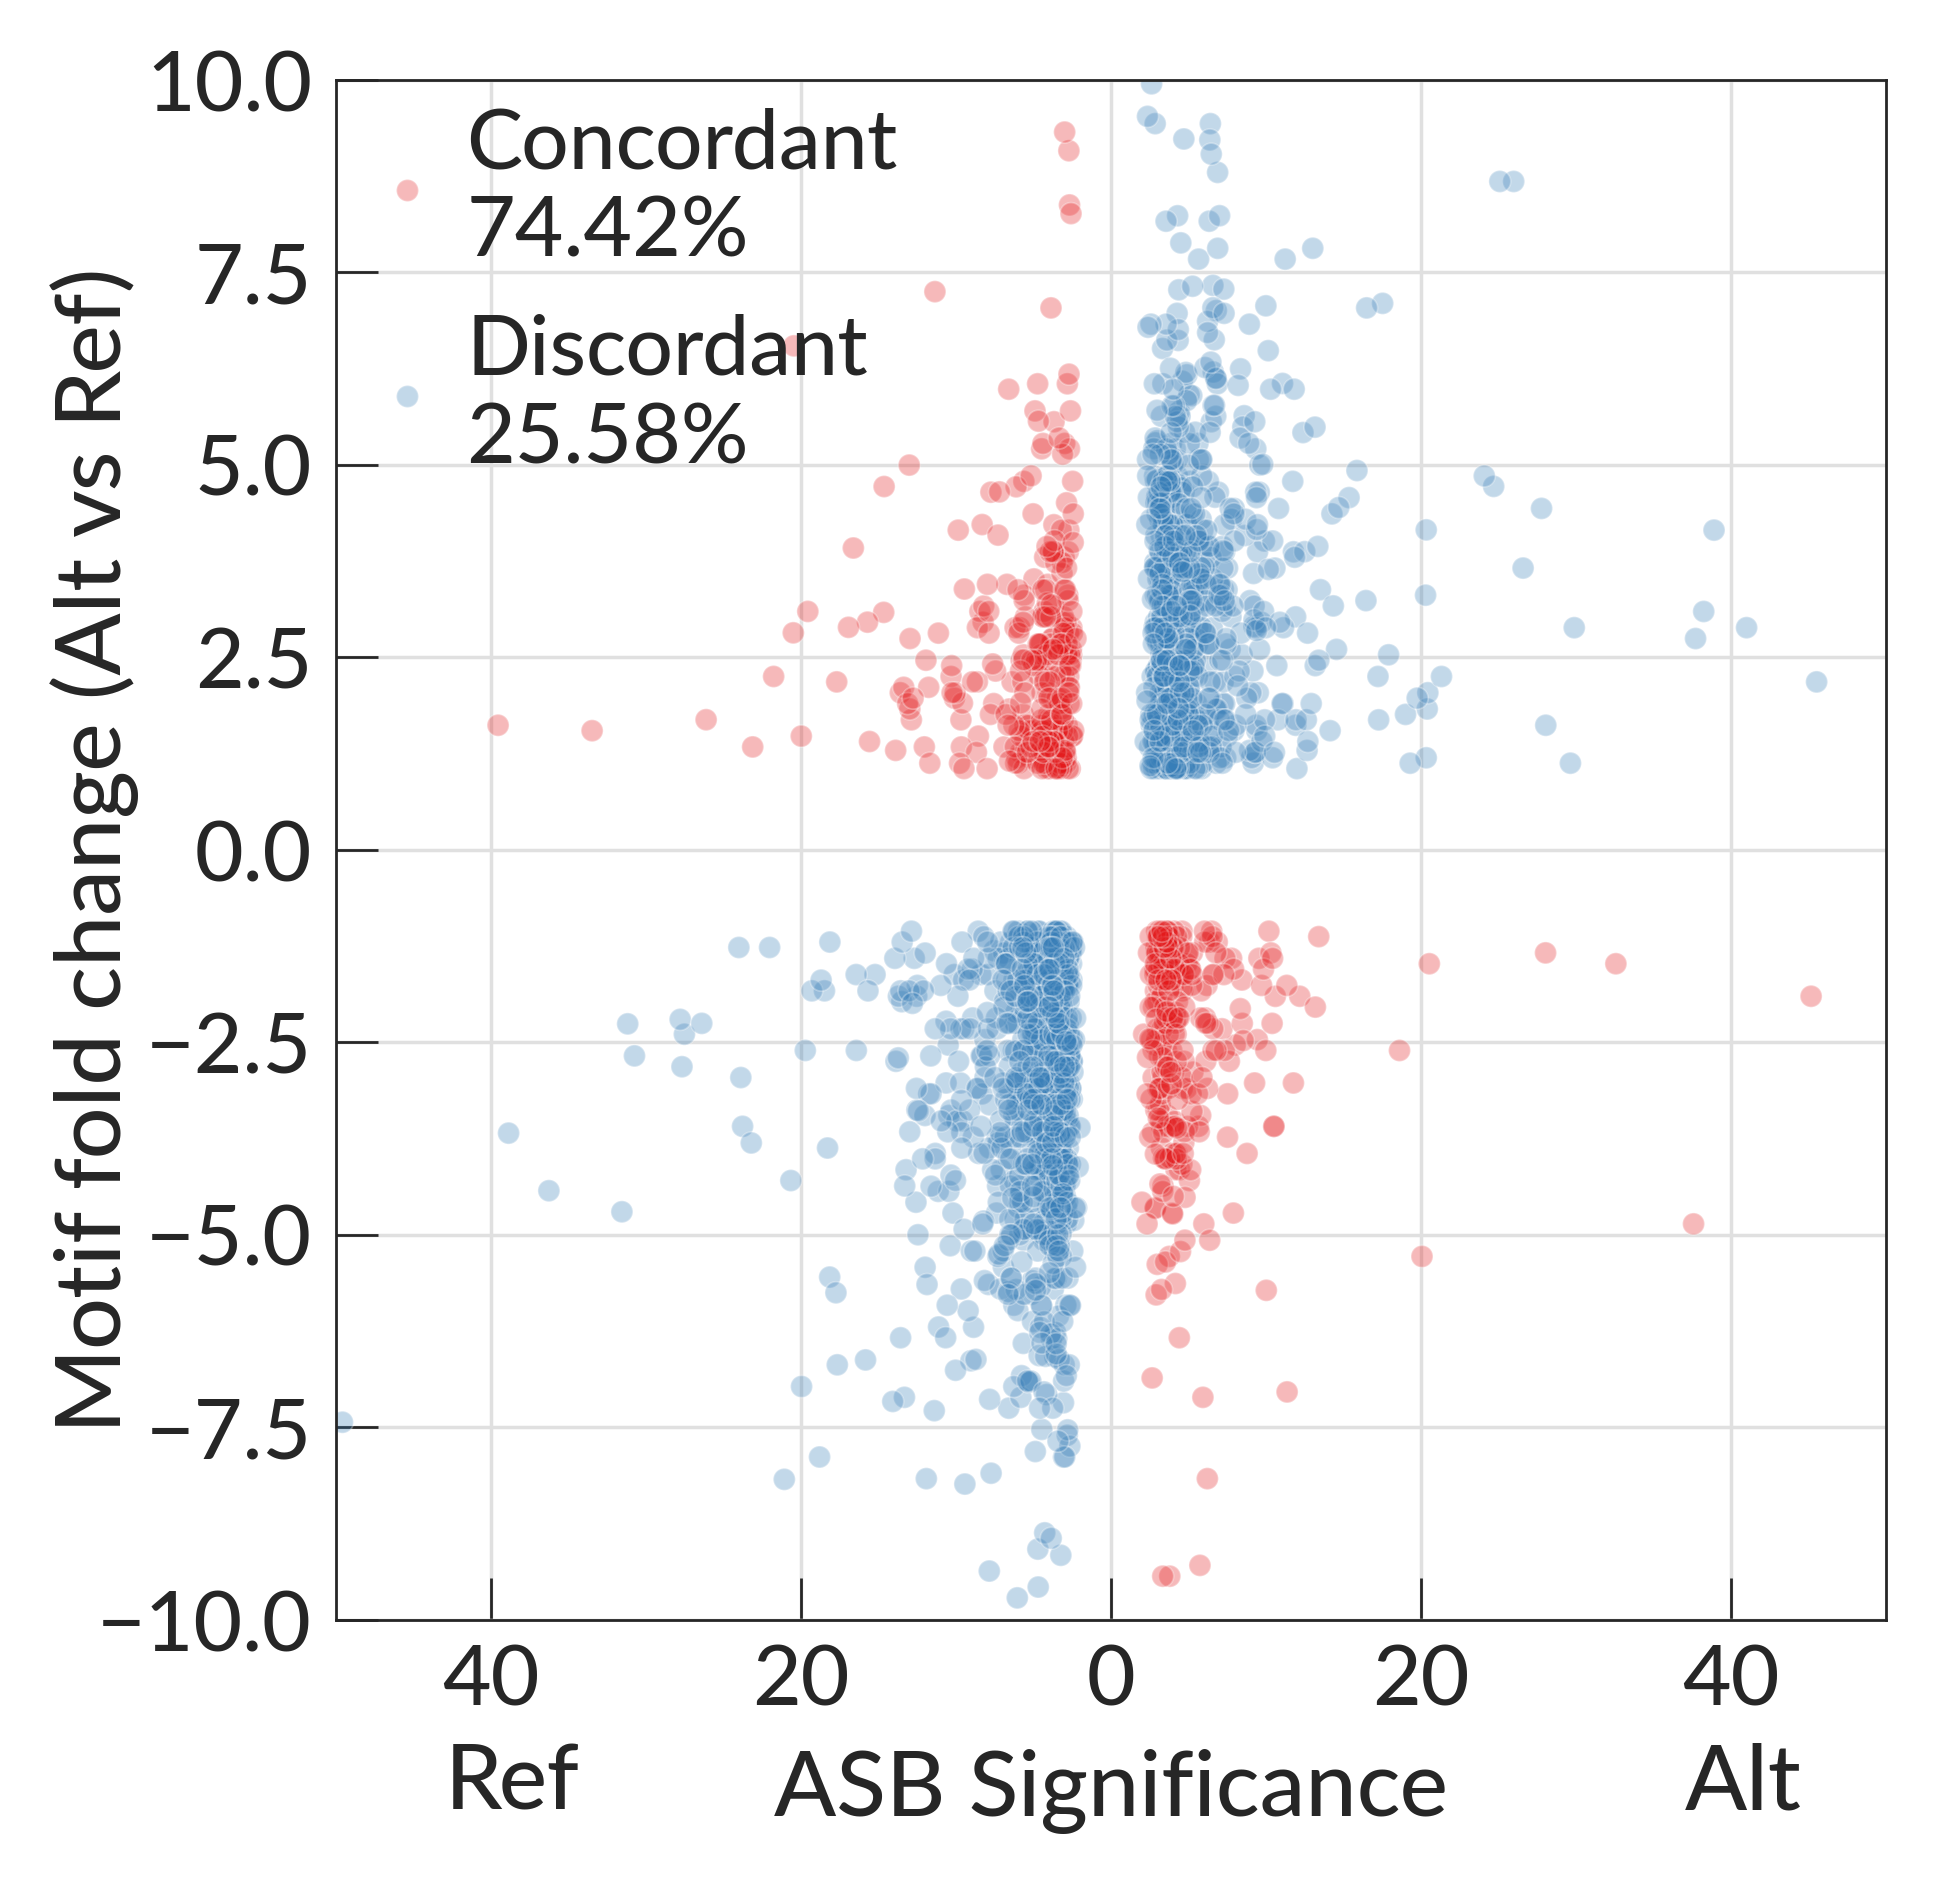

In [11]:
def fraction(series, word, words):
    return (series == word).sum() / series.isin(words).sum()


matplotlib.rcParams['font.weight'] = "medium"
matplotlib.rcParams['axes.labelweight'] = 'medium'
matplotlib.rcParams['figure.titleweight'] = 'medium'
matplotlib.rcParams['axes.titleweight'] = 'medium'
sns.set_style('whitegrid')
sns.set(font_scale=1.1, style="ticks", font="lato")
palette = ["#0072B2", "#D55E00"]

table = df.query('abs(motif_fc) > 1')

fig, axs = plt.subplots(figsize=(4, 4), dpi=500)

for a in ['top', 'bottom', 'right', 'left']:
    axs.spines[a].set_linewidth(0.4)
    
plt.ylim([0.05, 0.9])
plt.xlim([0, 4])
plt.grid(linewidth=0.5, which='both', color='#E0E0E0')
plt.tick_params(direction='in', width=0.4, which='major')
plt.tick_params(direction='out', width=0, which='minor')


plt.xlim([-50, 50])
plt.ylim([-10, 10])
ax = sns.scatterplot(data=table, x='signed_pvalue', y='motif_fc', hue='motif_conc',
                palette={'No Hit': sns.color_palette("Set1")[-1],
                         'Concordant': sns.color_palette("Set1")[1],
                         'Discordant': sns.color_palette("Set1")[0]},
               alpha=0.3, s=10)

handles, labels  =  ax.get_legend_handles_labels()
#handles = handles[0], handles[2]

legend = ax.legend(handles, [f"Concordant\n{fraction(table['motif_conc'], 'Concordant', ['Concordant', 'Discordant']):.2%}", 
                    f"Discordant\n{fraction(table['motif_conc'], 'Discordant', ['Concordant', 'Discordant']):.2%}"], 
          loc=(-0.03, 0.72), handletextpad=-0.3)
          
legend.get_frame().set_alpha(None)
#legend.get_frame().set_facecolor((1, 1, 1, 1))
legend.get_frame().set_facecolor((1, 1, 1, 0))
legend.get_frame().set_edgecolor((0, 0, 0, 0))
plt.xlabel('ASB Significance')
plt.text(-43, -12.45, 'Ref')
plt.text(37, -12.45, 'Alt')
xlabels = ax.get_xticklabels()
xticks = ax.get_xticks()
for label, tick in zip(xlabels, xticks):
    print(abs(int(tick)))
    label.set_text(abs(int(tick)))
ax.set_xticklabels(xlabels)
plt.ylabel('Motif fold change (Alt vs Ref)', labelpad=-6)
plt.savefig('figures/motif_concordance.pdf', bbox_inches='tight')
plt.savefig('figures/motif_concordance.png', bbox_inches='tight')

# Overall combine

In [2]:
chipseq = pd.read_table('/home/vladimirnoz/Projects/Codebook_Perspectives/AS_CHS_GHTS/as_tables_combine_everything/ASB_phenotypes/chipseq.tsv')
selex = pd.read_table('/home/vladimirnoz/Projects/Codebook_Perspectives/AS_CHS_GHTS/as_tables_combine_everything/ASB_phenotypes/selex.tsv')
main_table = pd.concat([chipseq, selex])

In [3]:
def remake_eqtl(row):
    dct = {'fdr': row['fdr_comb_pval'], 'associated': (row[['eQTL_cis', 'eQTL_trans']] != '-').any()}
    return pd.Series(dct)
def remake_adastra(row):
    dct = {'fdr': row['fdr_comb_pval'], 'associated': (row[['fdrp_bh_ref', 'fdrp_bh_alt']] < 0.05).any()}
    return pd.Series(dct)
def remake(row):
    dct = {'fdr': row['fdr_comb_pval'], 
           'eqtl': (row[['eQTL_cis', 'eQTL_trans']] != '-').any(),
            'adastra': (row[['fdrp_bh_ref', 'fdrp_bh_alt']] < 0.05).any()}
    return pd.Series(dct)

def get_adastra_hek293():
    adastra = []
    for x in glob('/home/vladimirnoz/Annotator/adastra_billcipher/release_dump/CL/HEK293*'):
        adastra.append(pd.read_table(x))
    return pd.concat(adastra)
        

def get_table(x):
    adastra = get_adastra_hek293()[['ID', 'fdrp_bh_ref', 'fdrp_bh_alt']]
    x = x.merge(adastra, left_on='id', right_on='ID', how='inner')
    t = x.apply(remake, axis=1)
    return t

In [4]:
table = get_table(main_table)

In [5]:
table

,fdr,eqtl,adastra
0,0.193873,True,False
1,0.615646,False,False
2,0.275182,True,False
3,0.275182,True,True
4,0.275182,True,False
...,...,...,...
110892,0.284301,True,False
110893,0.284301,True,False
110894,0.846399,True,False
110895,0.846399,True,False


In [8]:
def recalc(table, rowname):
    x = 10.0 ** np.linspace(0, -10, num=1000)
    y = []
    print('Calculating points')
    for fdr in tqdm(x):
        subtable = table.query(f'fdr <= {fdr}')
        y.append(subtable[rowname].sum()/len(subtable))
    return x, y
eqtl_plot = recalc(table, 'eqtl')
adastra_plot = recalc(table, 'adastra')


Calculating points


  0%|          | 0/1000 [00:00<?, ?it/s]

Calculating points


  0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
table['signif'] = table['fdr'] < 0.05
cont_eqtl = pd.crosstab(index=table['signif'], columns=table['eqtl'])
cont_adastra = pd.crosstab(index=table['signif'], columns=table['adastra'])
print(fisher_exact(cont_eqtl))
print(odds_ratio(cont_eqtl))
print(fisher_exact(cont_adastra))
print(odds_ratio(cont_adastra))

SignificanceResult(statistic=np.float64(1.225259740337376), pvalue=np.float64(3.9453630695522495e-28))
OddsRatioResult(statistic=1.2252575638008811)
SignificanceResult(statistic=np.float64(5.592511215620795), pvalue=np.float64(0.0))
OddsRatioResult(statistic=5.592381087052416)


In [16]:
list(table['signif']).count(True)

18181

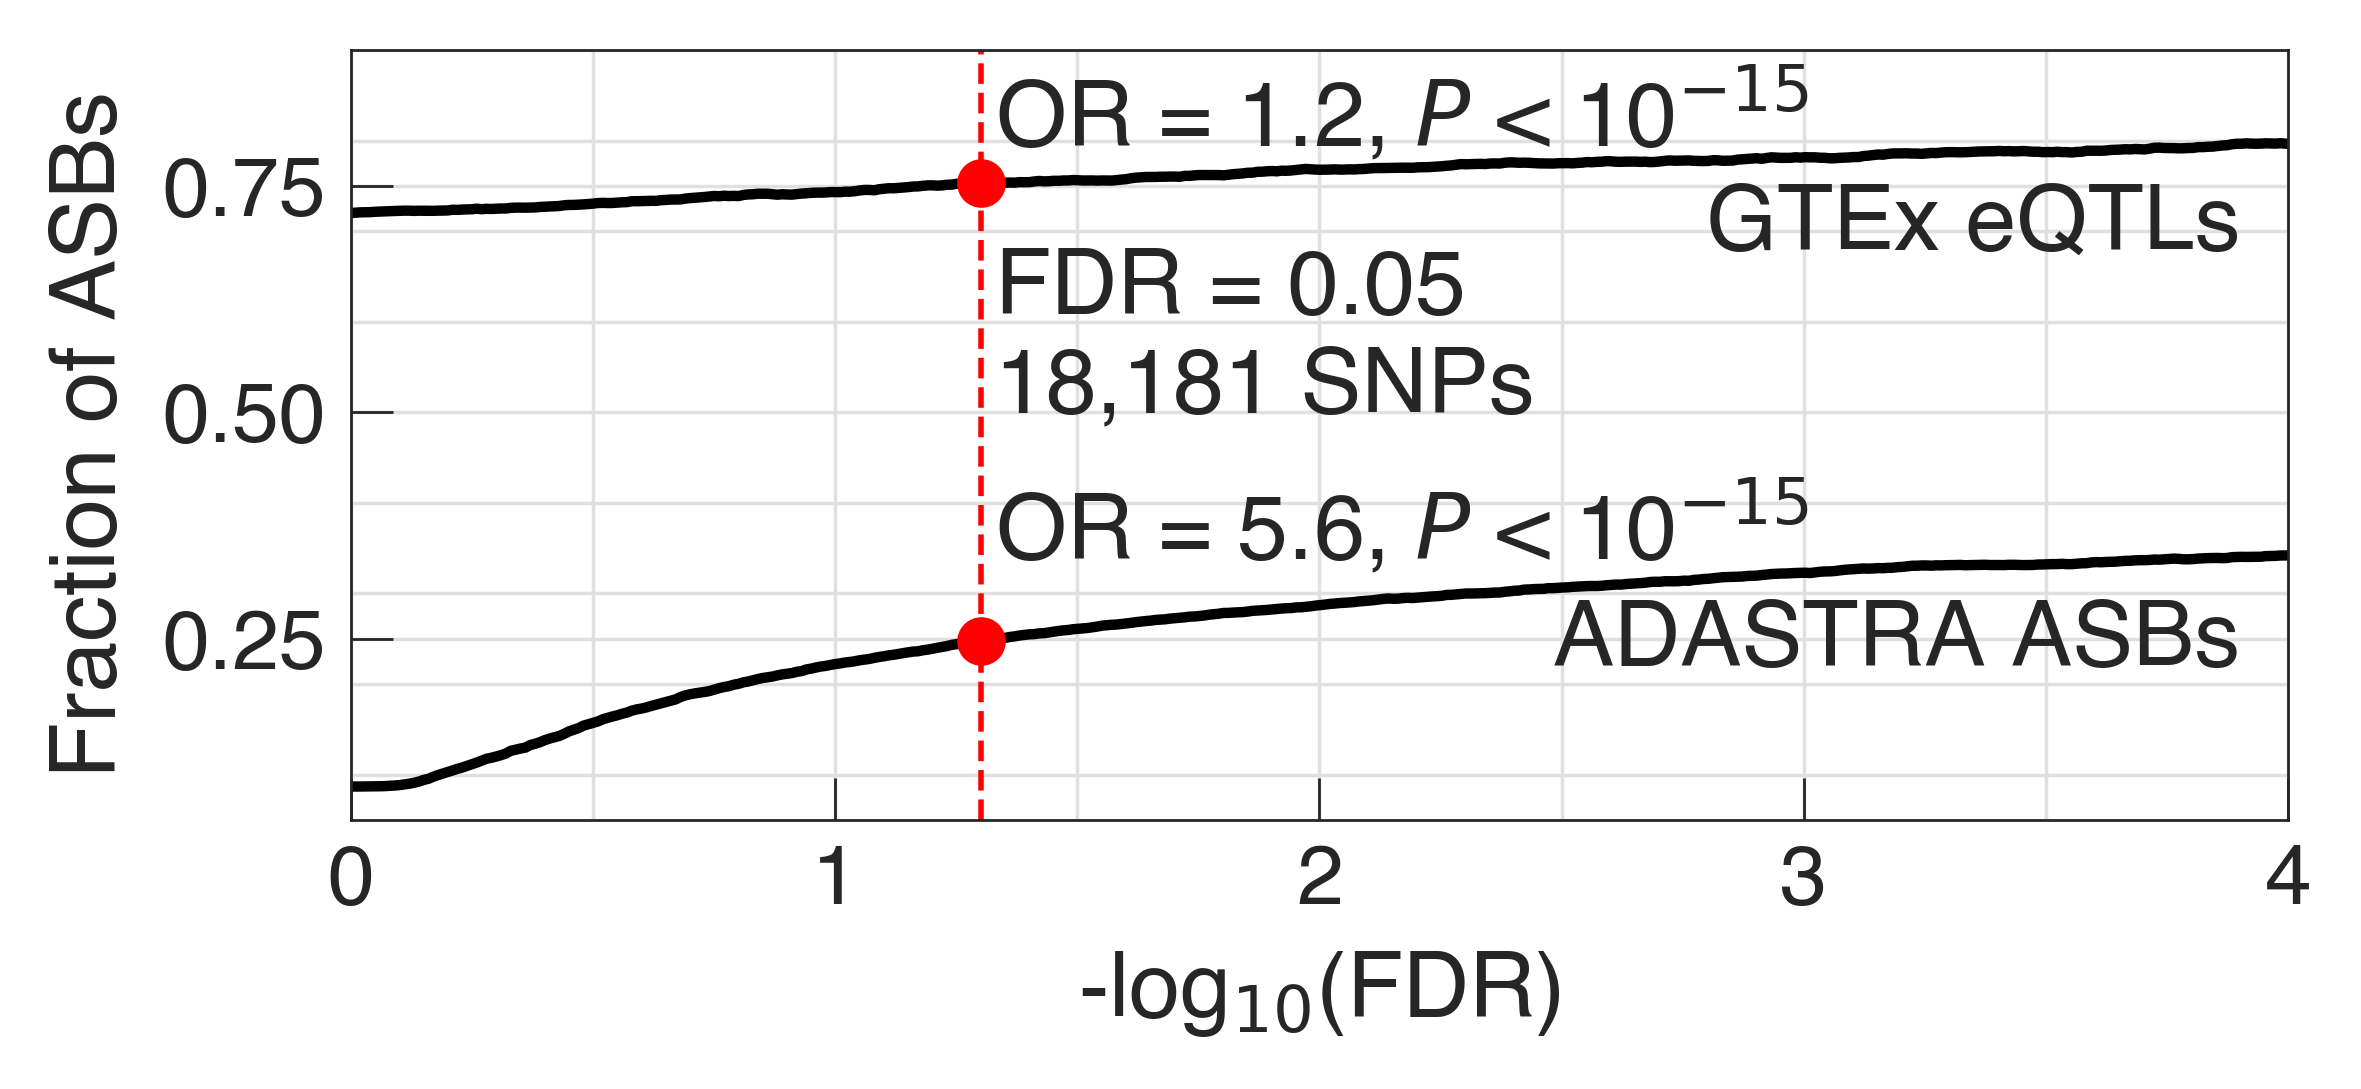

In [22]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.legend_handler import HandlerLine2D

matplotlib.rcParams['font.weight'] = "medium"
matplotlib.rcParams['axes.labelweight'] = 'medium'
matplotlib.rcParams['figure.titleweight'] = 'medium'
matplotlib.rcParams['axes.titleweight'] = 'medium'
sns.set_style('whitegrid')
sns.set(font_scale=1.1, style="ticks", font="helvetica")

fig, ax = plt.subplots(figsize=(5, 2), dpi=500)

for a in ['top', 'bottom', 'right', 'left']:
    ax.spines[a].set_linewidth(0.4)
plt.ylim([0.05, 0.9])
plt.xlim([0, 4])
plt.grid(linewidth=0.5, which='both', color='#E0E0E0')
plt.tick_params(direction='in', width=0.4, which='major')
plt.tick_params(direction='out', width=0, which='minor')
ax.xaxis.set_major_locator(MultipleLocator(1))
#ax.xaxis.set_major_formatter('{x:.0f}')

# For the minor ticks, use no labels; default NullFormatter.
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

eqtl_line, = plt.plot(-np.log10(eqtl_plot[0]), eqtl_plot[1], label='eQTL', color='#000000')
adastra_line, = plt.plot(-np.log10(adastra_plot[0]), adastra_plot[1], label='ADASTRA', color='#000000')

plt.xlabel('-log$_{10}$(FDR)')
plt.ylabel('Fraction of ASBs')

signif_x = -np.log10(0.05)
plt.axvline(signif_x, color="#FF0000", linestyle='--', linewidth=0.8)
index_of_05 = min(range(len(eqtl_plot[0])), key=lambda x: abs(eqtl_plot[0][x] - 0.05))
eqtl_point = eqtl_plot[1][index_of_05]
adastra_point = adastra_plot[1][index_of_05]
plt.plot([signif_x, signif_x], [eqtl_point, adastra_point], 'o', color="#FF0000")

plt.text(signif_x+0.03, adastra_point+0.09, 'OR = 5.6, $\it{P}$ < 10$^{-15}$')
plt.text(signif_x+0.03, eqtl_point+0.04, 'OR = 1.2, $\it{P}$ < 10$^{-15}$')
plt.text(signif_x+0.03, 0.5, 'FDR = 0.05\n18,181 SNPs')
plt.text(3.9, 0.22, 'ADASTRA ASBs', ha='right')
plt.text(3.9, 0.68, 'GTEx eQTLs', ha='right')



#legend = plt.legend(handlelength=0.8, handletextpad=0.3, loc=[0.65, 0.76])
#legend = plt.legend(handlelength=0.8, handletextpad=0.3, loc='lower right')
#legend.get_frame().set_alpha(None)
#legend.get_frame().set_facecolor((1, 1, 1, 1))
#legend.get_frame().set_facecolor((0, 0, 0, 0))
#legend.get_frame().set_edgecolor((0, 0, 0, 0))

plt.savefig('figures/fdr_thresholds_adastra_gtex.pdf', bbox_inches='tight')
plt.show()